# 03 — PCA Dimensionality Reduction Notebook

This notebook mirrors the PCA page and adds deeper mathematical/visual analysis: explained variance, cumulative variance, 2D/3D maps, loadings, biplot, feature contribution, and saved PCA score datasets.

## Rule

PCA uses one averaged row per country. Time is ignored here because PCA is meant to map country profiles, not yearly trends.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook paths: this assumes the notebooks folder is copied into your project root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATHS = [
    PROJECT_ROOT / "sample_datasets" / "world_panel_2010_2023.csv",
    PROJECT_ROOT / "data" / "raw" / "world_panel_2010_2023.csv",
    Path("/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/sample_datasets/world_panel_2010_2023.csv"),
]
DATA_PATH = next((p for p in DATA_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find world_panel_2010_2023.csv. Put this notebook folder in the project root.")

CHARTS_DIR = PROJECT_ROOT / "charts" / Path.cwd().name.replace(" ", "_")
if Path.cwd().name != "notebooks":
    # when executed from project root, use the notebook-specific folder manually below
    CHARTS_DIR = PROJECT_ROOT / "charts" / "03_pca"
PROCESSED_DIR = PROJECT_ROOT / "after_processing_dataset"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def save_mpl(name, dpi=160):
    path = CHARTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved chart: {path}")
    plt.show()

def save_df(df, name):
    path = PROCESSED_DIR / name
    df.to_csv(path, index=False)
    print(f"Saved dataset: {path}")
    return path

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head()

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_cols = df.select_dtypes(include="number").columns.tolist()
feature_cols = [c for c in numeric_cols if c != "year"]
country_profile = df.groupby(["country", "code", "region"], as_index=False)[feature_cols].mean()
X_imp = SimpleImputer(strategy="median").fit_transform(country_profile[feature_cols])
X = StandardScaler().fit_transform(X_imp)

Loaded: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/sample_datasets/world_panel_2010_2023.csv
Shape: (336, 22)


## 1. Fit full PCA and explained variance

In [2]:
pca_full = PCA(n_components=min(X.shape), random_state=42)
X_pca_full = pca_full.fit_transform(X)
explained = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca_full.explained_variance_ratio_))],
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_full.explained_variance_ratio_)
})
display(explained.round(4))
save_df(explained, "pca_explained_variance.csv")

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.9324,0.9324
1,PC2,0.0492,0.9816
2,PC3,0.0102,0.9918
3,PC4,0.0044,0.9961
4,PC5,0.0017,0.9978
5,PC6,0.0009,0.9987
6,PC7,0.0004,0.9992
7,PC8,0.0003,0.9995
8,PC9,0.0003,0.9997
9,PC10,0.0001,0.9998


Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/pca_explained_variance.csv


PosixPath('/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/pca_explained_variance.csv')

Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/pca_explained_variance.png


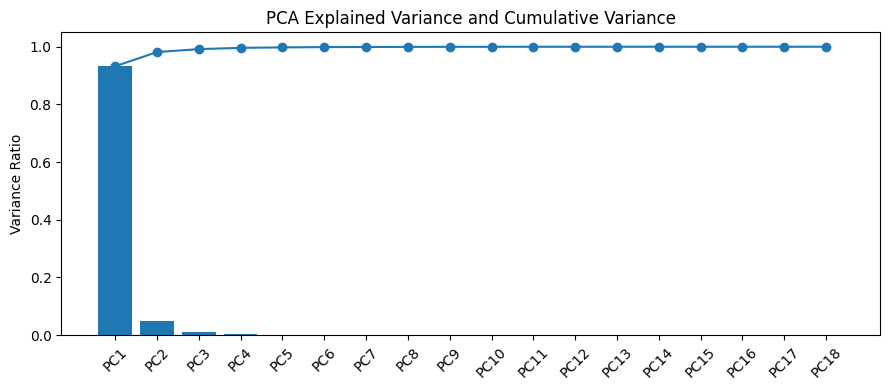

In [3]:
plt.figure(figsize=(9,4))
plt.bar(explained["component"], explained["explained_variance_ratio"])
plt.plot(explained["component"], explained["cumulative_variance"], marker="o")
plt.xticks(rotation=45)
plt.title("PCA Explained Variance and Cumulative Variance")
plt.ylabel("Variance Ratio")
save_mpl("pca_explained_variance.png")

## 2. PCA country map — 2D

,country,code,region,PC1,PC2
0,Algeria,DZA,Africa,-3.320247,1.368234
1,Australia,AUS,Oceania,5.246327,-0.197802
2,Brazil,BRA,Americas,-1.779923,0.640402
3,China,CHN,Asia,0.824856,-0.054939
4,Egypt,EGY,Africa,-2.990642,-0.157963


Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/pca_2d_country_scores.csv
Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/pca_2d_country_map.png


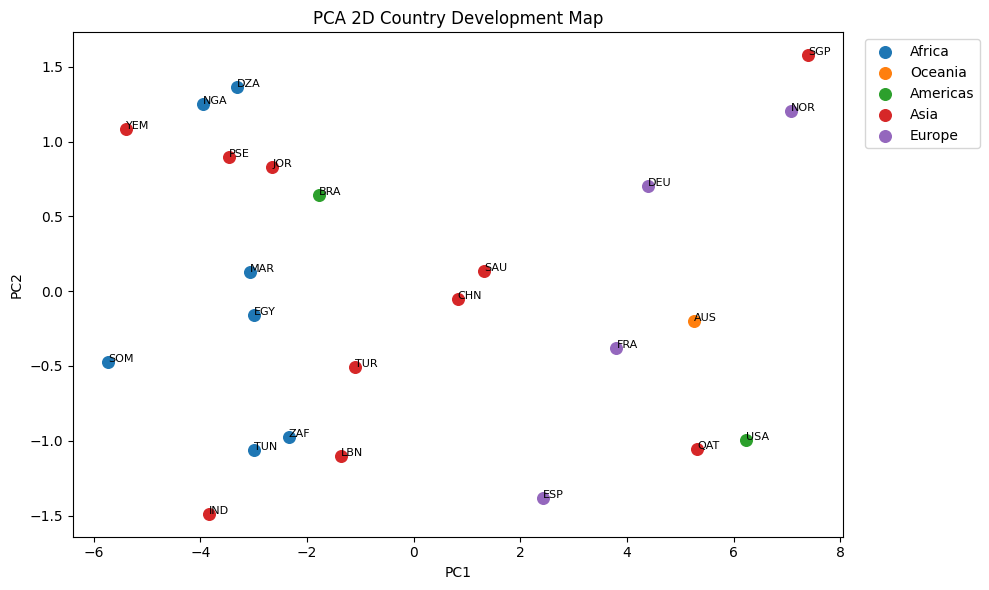

In [4]:
pca2 = PCA(n_components=2, random_state=42)
coords2 = pca2.fit_transform(X)
pca_scores = country_profile[["country", "code", "region"]].copy()
pca_scores["PC1"] = coords2[:,0]
pca_scores["PC2"] = coords2[:,1]
display(pca_scores.head())
save_df(pca_scores, "pca_2d_country_scores.csv")

plt.figure(figsize=(10,6))
for region in pca_scores["region"].unique():
    part = pca_scores[pca_scores["region"] == region]
    plt.scatter(part["PC1"], part["PC2"], s=70, label=region)
for _, r in pca_scores.iterrows():
    plt.text(r["PC1"], r["PC2"], r["code"], fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Country Development Map")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
save_mpl("pca_2d_country_map.png")

## 3. 3D PCA map

Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/pca_3d_country_scores.csv
Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/pca_3d_country_map.png


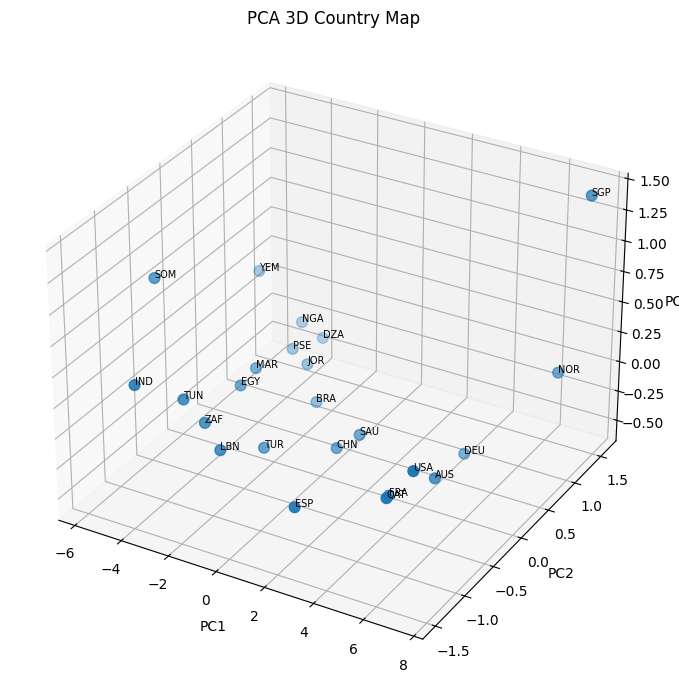

In [5]:
from mpl_toolkits.mplot3d import Axes3D
pca3 = PCA(n_components=3, random_state=42)
coords3 = pca3.fit_transform(X)
pca3_scores = country_profile[["country", "code", "region"]].copy()
pca3_scores[["PC1","PC2","PC3"]] = coords3
save_df(pca3_scores, "pca_3d_country_scores.csv")

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pca3_scores["PC1"], pca3_scores["PC2"], pca3_scores["PC3"], s=60)
for _, r in pca3_scores.iterrows():
    ax.text(r["PC1"], r["PC2"], r["PC3"], r["code"], fontsize=7)
ax.set_title("PCA 3D Country Map")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
save_mpl("pca_3d_country_map.png")

## 4. PCA loadings

Loadings show which original indicators influence each component.

In [6]:
loadings = pd.DataFrame(pca2.components_.T, index=feature_cols, columns=["PC1_loading", "PC2_loading"])
loadings["PC1_abs"] = loadings["PC1_loading"].abs()
loadings["PC2_abs"] = loadings["PC2_loading"].abs()
display(loadings.sort_values("PC1_abs", ascending=False).round(4))
save_df(loadings.reset_index().rename(columns={"index":"feature"}), "pca_loadings_pc1_pc2.csv")

,PC1_loading,PC2_loading,PC1_abs,PC2_abs
hdi,0.2440,0.0132,0.2440,0.0132
infant_mortality,-0.2440,-0.0109,0.2440,0.0109
urbanization_rate,0.2440,0.0156,0.2440,0.0156
maternal_mortality,-0.2440,-0.0044,0.2440,0.0044
fertility_rate,-0.2440,-0.0125,0.2440,0.0125
health_spending_pct,0.2437,0.0090,0.2437,0.0090
life_expectancy,0.2436,-0.0090,0.2436,0.0090
education_spending_pct,0.2435,0.0271,0.2435,0.0271
access_to_water_pct,0.2434,-0.0168,0.2434,0.0168
political_stability,0.2434,0.0272,0.2434,0.0272


Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/pca_loadings_pc1_pc2.csv


PosixPath('/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/pca_loadings_pc1_pc2.csv')

Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/pca_top_pc1_loadings.png


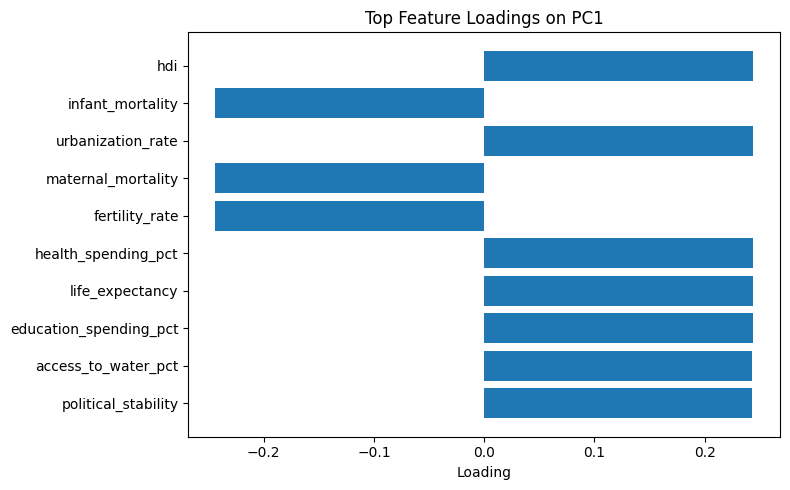

Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/pca_top_pc2_loadings.png


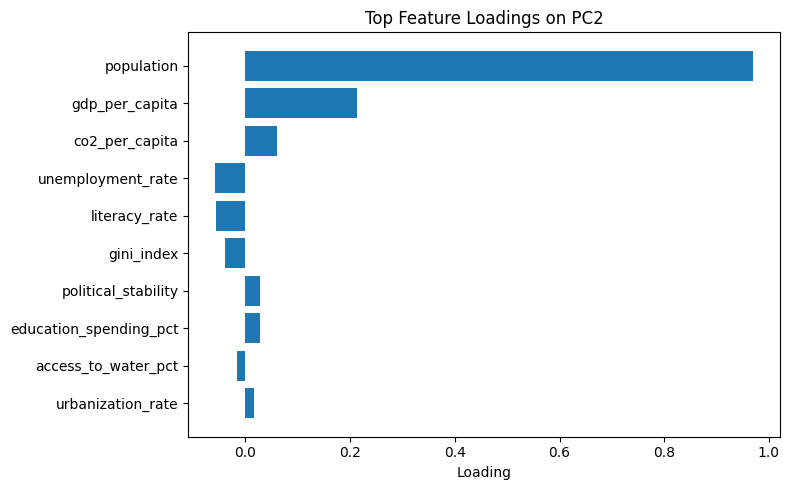

In [7]:
top_pc1 = loadings.sort_values("PC1_abs", ascending=False).head(10)
plt.figure(figsize=(8,5))
plt.barh(top_pc1.index[::-1], top_pc1["PC1_loading"][::-1])
plt.title("Top Feature Loadings on PC1")
plt.xlabel("Loading")
save_mpl("pca_top_pc1_loadings.png")

top_pc2 = loadings.sort_values("PC2_abs", ascending=False).head(10)
plt.figure(figsize=(8,5))
plt.barh(top_pc2.index[::-1], top_pc2["PC2_loading"][::-1])
plt.title("Top Feature Loadings on PC2")
plt.xlabel("Loading")
save_mpl("pca_top_pc2_loadings.png")

## 5. PCA biplot — countries + feature vectors

Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/pca_biplot.png


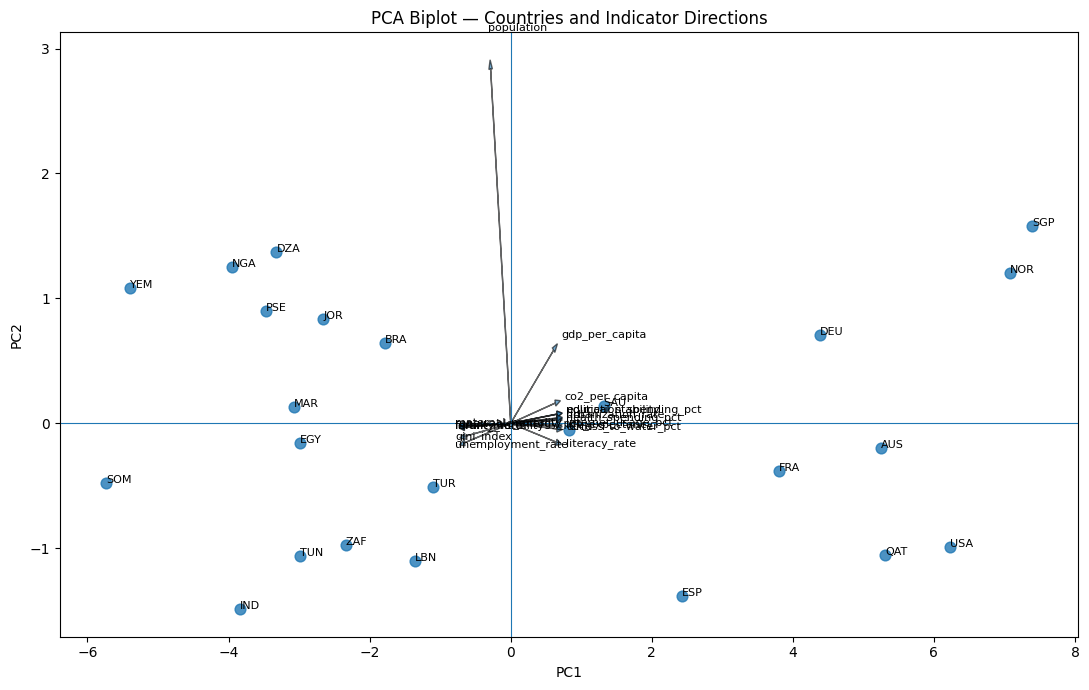

In [8]:
plt.figure(figsize=(11,7))
plt.scatter(pca_scores["PC1"], pca_scores["PC2"], s=60, alpha=0.8)
for _, r in pca_scores.iterrows():
    plt.text(r["PC1"], r["PC2"], r["code"], fontsize=8)
scale = 3.0
for feat in feature_cols:
    x = loadings.loc[feat, "PC1_loading"] * scale
    y = loadings.loc[feat, "PC2_loading"] * scale
    plt.arrow(0, 0, x, y, head_width=0.05, length_includes_head=True, alpha=0.6)
    plt.text(x*1.08, y*1.08, feat, fontsize=8)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("PCA Biplot — Countries and Indicator Directions")
plt.xlabel("PC1")
plt.ylabel("PC2")
save_mpl("pca_biplot.png")

## 6. Loading heatmap

Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/pca_loading_heatmap_first_6.png


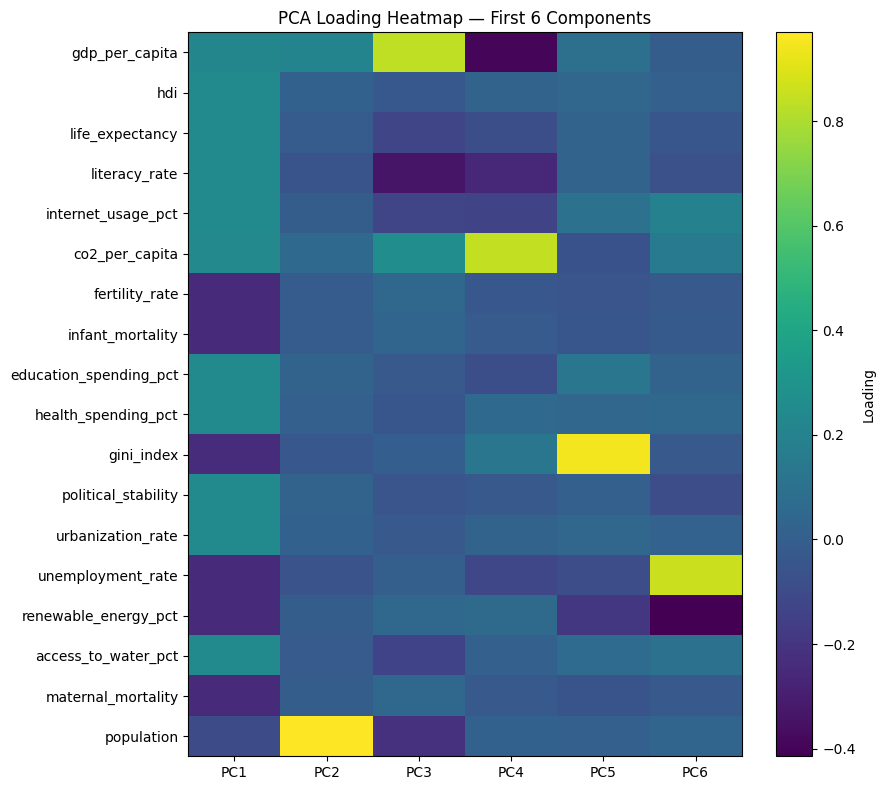

Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/pca_loading_matrix_first_6.csv


PosixPath('/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/pca_loading_matrix_first_6.csv')

In [9]:
loading_matrix = pd.DataFrame(pca_full.components_.T[:, :6], index=feature_cols, columns=[f"PC{i}" for i in range(1,7)])
plt.figure(figsize=(9,8))
plt.imshow(loading_matrix, aspect="auto")
plt.colorbar(label="Loading")
plt.xticks(range(loading_matrix.shape[1]), loading_matrix.columns)
plt.yticks(range(loading_matrix.shape[0]), loading_matrix.index)
plt.title("PCA Loading Heatmap — First 6 Components")
save_mpl("pca_loading_heatmap_first_6.png")
save_df(loading_matrix.reset_index().rename(columns={"index":"feature"}), "pca_loading_matrix_first_6.csv")

## 7. Interpretation helper

In [10]:
pc1_positive = loadings.sort_values("PC1_loading", ascending=False).head(5).index.tolist()
pc1_negative = loadings.sort_values("PC1_loading", ascending=True).head(5).index.tolist()
pc2_positive = loadings.sort_values("PC2_loading", ascending=False).head(5).index.tolist()
pc2_negative = loadings.sort_values("PC2_loading", ascending=True).head(5).index.tolist()
print("PC1 positive drivers:", pc1_positive)
print("PC1 negative drivers:", pc1_negative)
print("PC2 positive drivers:", pc2_positive)
print("PC2 negative drivers:", pc2_negative)

PC1 positive drivers: ['hdi', 'urbanization_rate', 'health_spending_pct', 'life_expectancy', 'education_spending_pct']
PC1 negative drivers: ['infant_mortality', 'maternal_mortality', 'fertility_rate', 'renewable_energy_pct', 'unemployment_rate']
PC2 positive drivers: ['population', 'gdp_per_capita', 'co2_per_capita', 'political_stability', 'education_spending_pct']
PC2 negative drivers: ['unemployment_rate', 'literacy_rate', 'gini_index', 'access_to_water_pct', 'fertility_rate']
